In [1]:
import pandas as pd
import numpy as np
import duckdb
import faiss
import os
import pickle
from sentence_transformers import SentenceTransformer

In [2]:
import sys
sys.path.insert(0, '..')
from src.retrieval.retriever import generate_track_description

In [3]:
CATALOG_PATH = '../data/catalog.parquet'
DATA_DIR = '../data/'

In [4]:
catalog = duckdb.query(f"""
    SELECT track_id, title, artist_name, genre_top,
           valence, energy, danceability, acousticness,
           instrumentalness, tempo_norm, speechiness,
           valence_reliable
    FROM '{CATALOG_PATH}'
""").df()

In [5]:
print("Loaded:", catalog.shape)
print(catalog.head(3))

Loaded: (13129, 12)
   track_id         title artist_name genre_top   valence    energy  \
0         2          Food        AWOL   Hip-Hop  0.576661  0.634476   
1         3  Electric Ave        AWOL   Hip-Hop  0.269240  0.817461   
2         5    This World        AWOL   Hip-Hop  0.621661  0.701470   

   danceability  acousticness  instrumentalness  tempo_norm  speechiness  \
0      0.675894      0.416675          0.010628    0.642706     0.159310   
1      0.528643      0.374408          0.001851    0.479206     0.461818   
2      0.745566      0.043567          0.000697    0.367184     0.124595   

   valence_reliable  
0              True  
1              True  
2              True  


In [6]:
features_of_interest = ['valence', 'energy', 'acousticness', 
                         'instrumentalness', 'speechiness']

thresholds = {}
for feature in features_of_interest:
    thresholds[feature] = {
        'p25': catalog[feature].quantile(0.25),
        'p50': catalog[feature].quantile(0.50),
        'p75': catalog[feature].quantile(0.75),
    }
    print(f"{feature}:")
    print(f"  p25={thresholds[feature]['p25']:.3f}  "
          f"p50={thresholds[feature]['p50']:.3f}  "
          f"p75={thresholds[feature]['p75']:.3f}")
    print()

valence:
  p25=0.197  p50=0.418  p75=0.666

energy:
  p25=0.321  p50=0.549  p75=0.776

acousticness:
  p25=0.104  p50=0.574  p75=0.921

instrumentalness:
  p25=0.323  p50=0.838  p75=0.918

speechiness:
  p25=0.037  p50=0.049  p75=0.085



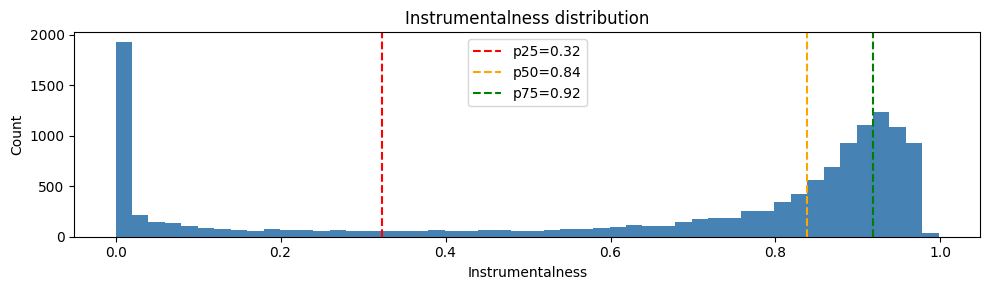

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.hist(catalog['instrumentalness'], bins=50, color='steelblue', edgecolor='none')
plt.axvline(thresholds['instrumentalness']['p25'], color='red', 
            linestyle='--', label=f"p25={thresholds['instrumentalness']['p25']:.2f}")
plt.axvline(thresholds['instrumentalness']['p50'], color='orange',
            linestyle='--', label=f"p50={thresholds['instrumentalness']['p50']:.2f}")
plt.axvline(thresholds['instrumentalness']['p75'], color='green',
            linestyle='--', label=f"p75={thresholds['instrumentalness']['p75']:.2f}")
plt.xlabel('Instrumentalness')
plt.ylabel('Count')
plt.title('Instrumentalness distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Filter to reliable valence tracks only before generating descriptions
# These boundary values are Echonest artifacts, not real measurements
catalog = catalog[catalog['valence_reliable'] == True].reset_index(drop=True)

print(f"Catalog size after filtering: {len(catalog)} tracks")

catalog['description'] = catalog.apply(
    generate_track_description, axis=1
)

sample = catalog.nlargest(3, 'valence')[['title', 'valence', 'energy', 'description']]
sample = pd.concat([
    sample,
    catalog.nsmallest(3, 'valence')[['title', 'valence', 'energy', 'description']]
])

for _, row in sample.iterrows():
    print(f"\n{row['title']} (valence={row['valence']:.2f}, energy={row['energy']:.2f})")
    print(f"  → {row['description']}")

Catalog size after filtering: 11868 tracks

Something Strange Happens (valence=0.95, energy=0.91)
  → A Pop track that feels explosive, unstoppable, fierce. The music is electronic and vocal.

City Kids (valence=0.95, energy=0.65)
  → A track that feels euphoric, exuberant, radiant. The music is acoustic and instrumental.

Kodak Nancy Europe (valence=0.95, energy=0.60)
  → A Rock track that feels euphoric, exuberant, radiant. The music is electronic and instrumental.

satellite (valence=0.05, energy=0.71)
  → A Rock track that feels anguished, tortured, harrowing. The music is acoustic and instrumental.

Ever Somber (valence=0.05, energy=0.61)
  → A Hip-Hop track that feels anguished, tortured, harrowing. The music is mixed and instrumental.

Midnightman (valence=0.05, energy=0.66)
  → A Electronic track that feels anguished, tortured, harrowing. The music is electronic and instrumental.


In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model max sequence length:", model.max_seq_length)
print("Embedding dimensions:", model.get_embedding_dimension())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model max sequence length: 256
Embedding dimensions: 384


In [11]:
print(f"Embedding {len(catalog)} track descriptions...")

descriptions = catalog['description'].tolist()

# batch_size=64 -- 64 descriptions processed at a time
embeddings = model.encode(
    descriptions,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True   # FAISS needs numpy arrays, not tensors
)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Each track is now a vector of {embeddings.shape[1]} numbers")

Embedding 11868 track descriptions...


Batches:   0%|          | 0/186 [00:00<?, ?it/s]


Embeddings shape: (11868, 384)
Each track is now a vector of 384 numbers


In [12]:
dimension = embeddings.shape[1]

faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print(f"Index built with {index.ntotal} vectors")
print(f"Index type: exact search (IndexFlatIP)")

Index built with 11868 vectors
Index type: exact search (IndexFlatIP)


In [13]:
faiss.write_index(index, os.path.join(DATA_DIR, 'track_index.faiss'))

track_id_map = catalog['track_id'].tolist()
with open(os.path.join(DATA_DIR, 'track_id_map.pkl'), 'wb') as f:
    pickle.dump(track_id_map, f)

print("Saved:")
print(f"  track_index.faiss  — the searchable vector index")
print(f"  track_id_map.pkl   — position → track_id mapping")

index_size = os.path.getsize(os.path.join(DATA_DIR, 'track_index.faiss'))
print(f"\nIndex file size: {index_size / 1024 / 1024:.1f} MB")

Saved:
  track_index.faiss  — the searchable vector index
  track_id_map.pkl   — position → track_id mapping

Index file size: 17.4 MB


In [16]:
def search_tracks(query_text, k=5):
    query_vector = model.encode([query_text], convert_to_numpy=True)
    faiss.normalize_L2(query_vector)
    
    scores, positions = index.search(query_vector, k)
    
    results = []
    for score, pos in zip(scores[0], positions[0]):
        track_id = track_id_map[pos]
        track = catalog[catalog['track_id'] == track_id].iloc[0]
        results.append({
            'title': track['title'],
            'artist': track['artist_name'],
            'genre': track['genre_top'],
            'valence': round(track['valence'], 3),
            'energy': round(track['energy'], 3),
            'similarity': round(float(score), 3),
            'description': track['description']
        })
    
    return results

# test_queries = [
#     "I feel melancholy and tired, want something that matches my mood",
#     "I need high energy music to get through a workout",
#     "Something calm and peaceful for late night reading",
#     "I'm feeling nostalgic and bittersweet"
# ]

test_queries = [
    "I feel sad and anxious",
    "I feel uneasy and sick",
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 60)
    results = search_tracks(query, k=3)
    for r in results:
        print(f"  {r['title']} — {r['artist']}")
        print(f"  valence={r['valence']}, energy={r['energy']}, similarity={r['similarity']}")
        print(f"  [{r['description']}]")


Query: 'I feel sad and anxious'
------------------------------------------------------------
  Floatin' — Brother JT
  valence=0.15, energy=0.98, similarity=0.35
  [A Blues track that feels tense, anxious, uneasy. The music is acoustic and instrumental.]
  Odete (remix 2006) — Chico Correa and Electronic Band
  valence=0.139, energy=0.915, similarity=0.346
  [A track that feels tense, anxious, uneasy. The music is mixed and instrumental.]
  Bang — D'r Sjaak
  valence=0.14, energy=0.854, similarity=0.346
  [A track that feels tense, anxious, uneasy. The music is mixed and instrumental.]

Query: 'I feel uneasy and sick'
------------------------------------------------------------
  Ghosts pt. 2 — Shlohmo
  valence=0.242, energy=0.759, similarity=0.379
  [A Hip-Hop track that feels tense, anxious, uneasy. The music is mixed and instrumental.]
  From Mole Hills — Dälek
  valence=0.202, energy=0.912, similarity=0.379
  [A Hip-Hop track that feels tense, anxious, uneasy. The music is mixed 